# Skin Lesion Classification: Melanoma vs Nevus
## Applied ML Assignment 5

Group Members: Sergi Cases and Martí Pascual


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

#for better plots
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

TRAIN_DIR = 'a5_data_new/train'
VAL_DIR   = 'a5_data_new/val'
TEST_DIR  = 'a5_data_test/test'

BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 1e-3
IMAGE_SIZE  = 128
NUM_CLASSES = 2      # MEL=0, NV=1 (ImageFolder: alphanumeric order)


PALETTE = {
    'MEL':  '#e74c3c',   # red
    'NV':   '#3498db',   # blue
    'train':'#2ecc71',
    'val':  '#e67e22',
}

## Data Loading and Visualisation

In [3]:
def get_basic_transform(image_size=IMAGE_SIZE):
    """Standard transform: resize → tensor → normalise with ImageNet stats."""
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

def get_augmented_transform(image_size=IMAGE_SIZE):
    """Augmented transform: random flips, rotation, colour jitter."""
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

def make_loaders(train_transform, val_transform,
                 train_dir=TRAIN_DIR, val_dir=VAL_DIR,
                 batch_size=BATCH_SIZE):
    train_ds = ImageFolder(train_dir, transform=train_transform)
    val_ds   = ImageFolder(val_dir,   transform=val_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f'Classes (alphabetical): {train_ds.classes}  →  MEL=0, NV=1')
    print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')
    return train_loader, val_loader

def unnormalise(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose(1, 2, 0)
    return np.clip(std * img + mean, 0, 1)

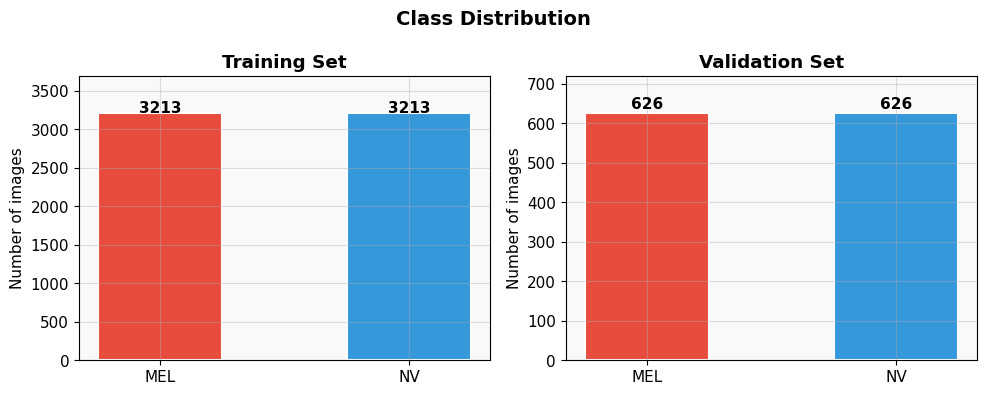

In [ ]:
#  Class distribution
basic_tf = get_basic_transform()
train_ds_vis = ImageFolder(TRAIN_DIR, transform=basic_tf)
val_ds_vis   = ImageFolder(VAL_DIR,   transform=basic_tf)

train_counts = np.bincount([y for _, y in train_ds_vis])
val_counts   = np.bincount([y for _, y in val_ds_vis])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes, [train_counts, val_counts], ['Training Set', 'Validation Set']):
    bars = ax.bar(['MEL', 'NV'], counts, color=[PALETTE['MEL'], PALETTE['NV']],
                  edgecolor='white', linewidth=1.5, width=0.5)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(c), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of images')
    ax.set_ylim(0, max(counts) * 1.15)
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

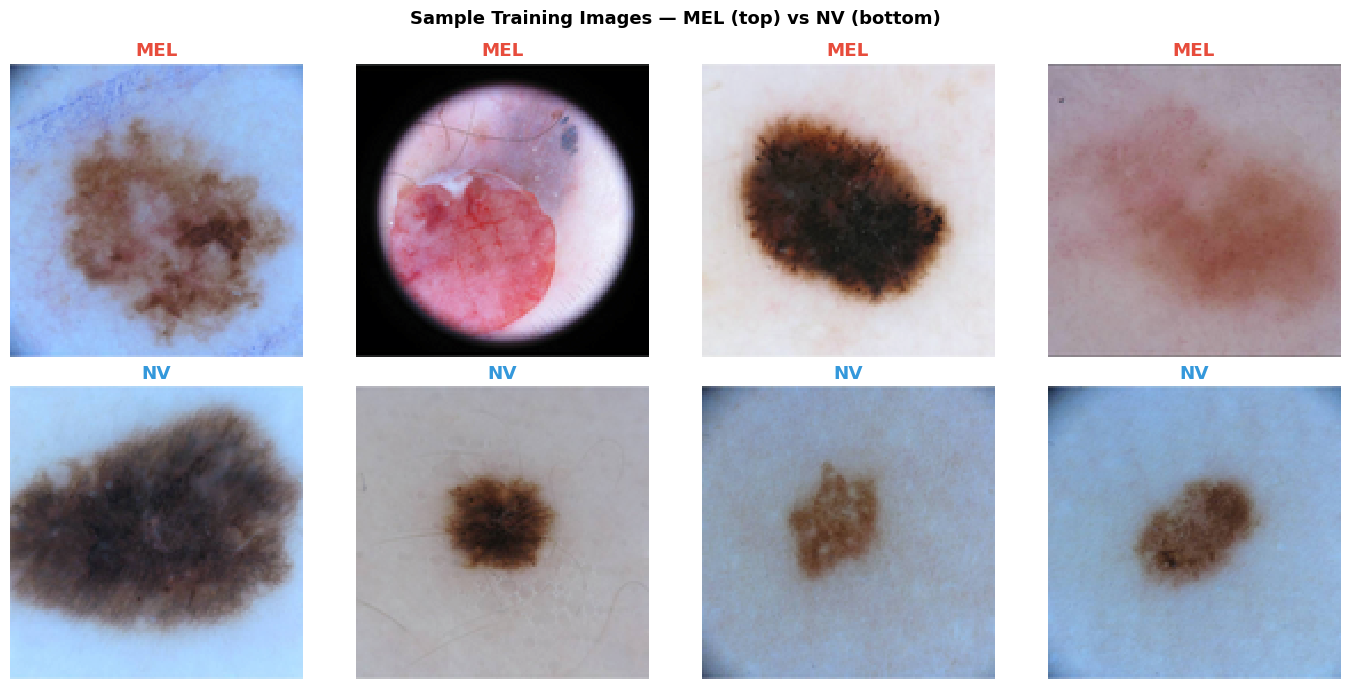

In [ ]:
# Sample images 
mel_imgs, nv_imgs = [], []
for img, label in train_ds_vis:
    if label == 0 and len(mel_imgs) < 4:
        mel_imgs.append(unnormalise(img))
    elif label == 1 and len(nv_imgs) < 4:
        nv_imgs.append(unnormalise(img))
    if len(mel_imgs) == 4 and len(nv_imgs) == 4:
        break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, img in enumerate(mel_imgs):
    axes[0, i].imshow(img, interpolation='none')
    axes[0, i].set_title('MEL', color=PALETTE['MEL'], fontweight='bold')
    axes[0, i].axis('off')
for i, img in enumerate(nv_imgs):
    axes[1, i].imshow(img, interpolation='none')
    axes[1, i].set_title('NV', color=PALETTE['NV'], fontweight='bold')
    axes[1, i].axis('off')
fig.suptitle('Sample Training Images — MEL (top) vs NV (bottom)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

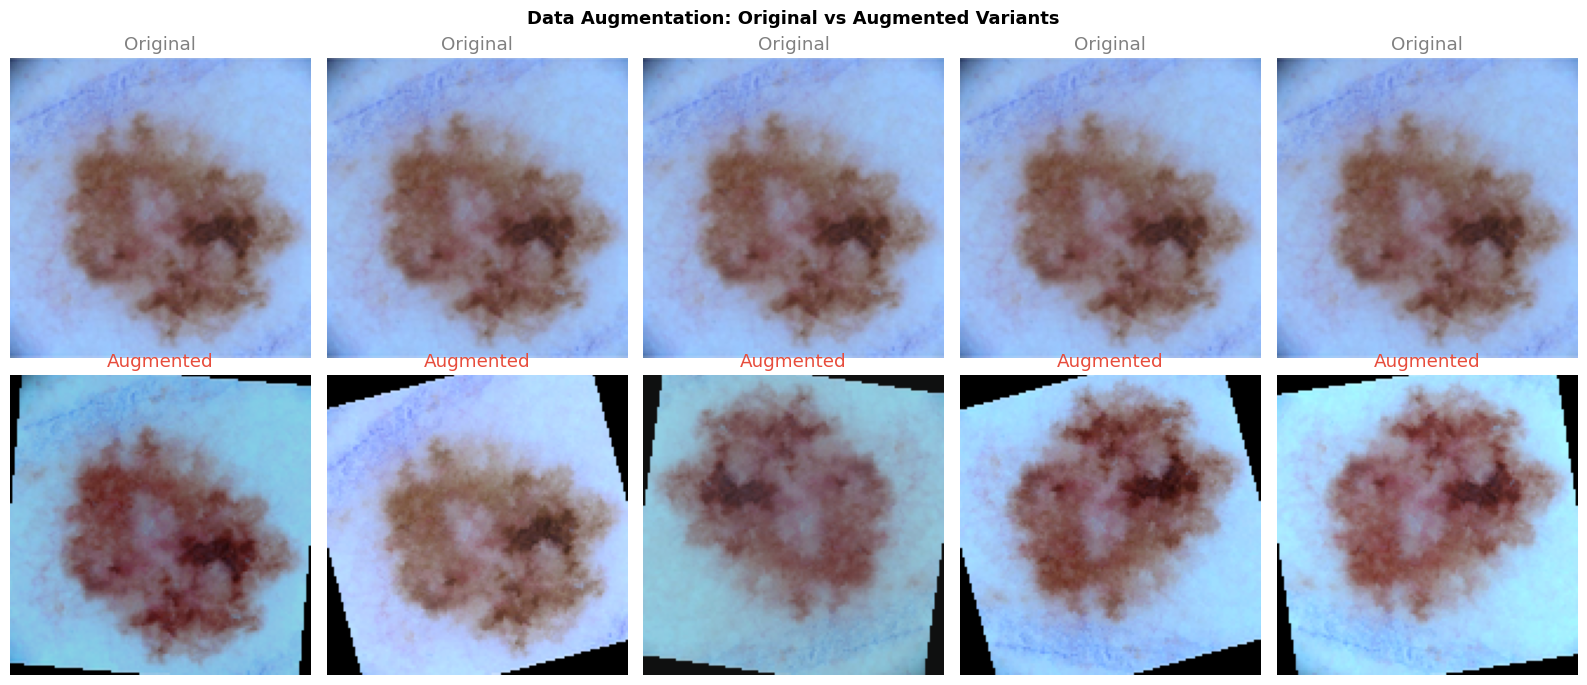

In [ ]:
# augmentation visualisation
# 
aug_tf = get_augmented_transform()

# grab one MEL image path and apply both transforms
from PIL import Image
import torchvision.transforms.functional as F

mel_path = None
for root, _, files in os.walk(os.path.join(TRAIN_DIR, 'MEL')):
    for f in files:
        if f.lower().endswith('.png'):
            mel_path = os.path.join(root, f)
            break
    if mel_path:
        break

if mel_path:
    raw_img = Image.open(mel_path).convert('RGB')
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    # top row is the original
    for ax in axes[0]:
        ax.imshow(raw_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
        ax.set_title('Original', color='gray')
        ax.axis('off')
    # bottom row 5 random augmentations
    for ax in axes[1]:
        aug_tensor = aug_tf(raw_img)
        ax.imshow(unnormalise(aug_tensor))
        ax.set_title('Augmented', color=PALETTE['MEL'])
        ax.axis('off')
    fig.suptitle('Data Augmentation: Original vs Augmented Variants',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

## Model Architectures

In [ ]:
class BaselineCNN(nn.Module):
    #Plain 3-block CNN 
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))


class BatchNormCNN(nn.Module):
    #Same as baseline but BatchNorm2d after each conv + Dropout in head
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))


class ResidualBlock(nn.Module):
    #Two conv layers with identity skip connection: output = F(x) + x
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.block(x))


class ResidualCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.stem  = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.res1  = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2)
        self.proj  = nn.Sequential(nn.Conv2d(64, 128, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.res2  = ResidualBlock(128)
        self.pool2 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.stem(x); x = self.pool1(self.res1(x))
        x = self.proj(x); x = self.pool2(self.res2(x))
        return self.classifier(x)


class BestModel(nn.Module):
    #Deeper residual CNN (3 blocks, 64->128->256) with dropout. Trained with augmentation
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.stem  = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.res1  = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2)
        self.proj1 = nn.Sequential(nn.Conv2d(64, 128, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.res2  = ResidualBlock(128)
        self.proj2 = nn.Sequential(nn.Conv2d(128, 256, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.res3  = ResidualBlock(256)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.stem(x); x = self.pool1(self.res1(x))
        x = self.proj1(x); x = self.res2(x)
        x = self.proj2(x); x = self.res3(x)
        return self.classifier(x)

## Training and evaluation funtions

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item() * X.size(0)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total   += X.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(model, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=LR, model_name='model'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
        scheduler.step(vl_acc)
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],
                         [tr_loss, tr_acc, vl_loss, vl_acc]):
            history[k].append(v)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'[{model_name}] Ep {epoch:02d}/{num_epochs}  '
              f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
              f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    if best_state:
        model.load_state_dict(best_state)
    print(f'\n>>> Best val accuracy [{model_name}]: {best_val_acc:.4f}\n')
    return history, best_val_acc

In [ ]:


def plot_history(history, model_name='model', save=True):
    """Training curves: loss and accuracy on same figure."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ep = range(1, len(history['train_loss']) + 1)

    for ax, metric in zip(axes, ['loss', 'acc']):
        tr_key, vl_key = f'train_{metric}', f'val_{metric}'
        ax.plot(ep, history[tr_key], color=PALETTE['train'],
                lw=2, marker='o', markersize=4, label='Train')
        ax.plot(ep, history[vl_key], color=PALETTE['val'],
                lw=2, marker='s', markersize=4, label='Val')
        # Highlight best val epoch
        best_ep = int(np.argmax(history['val_acc'])) + 1 if metric == 'acc' \
                  else int(np.argmin(history['val_loss'])) + 1
        best_val = history[vl_key][best_ep - 1]
        ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.5)
        ax.annotate(f'Best: {best_val:.4f}',
                    xy=(best_ep, best_val), xytext=(best_ep + 0.5, best_val),
                    fontsize=9, color='gray')
        ax.set_title(f'{model_name} — {metric.capitalize()}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend()

    plt.tight_layout()
    if save:
        plt.savefig(f'{model_name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, class_names, title='', save=True):
    """Confusion matrix with counts and row-normalised percentages."""
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, data, fmt, t in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],
        [f'{title}\nCounts', f'{title}\nRow-normalised']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    cmap='Blues', linewidths=0.5)
        ax.set_title(t, fontweight='bold')
        ax.set_ylabel('True'); ax.set_xlabel('Predicted')

    plt.tight_layout()
    if save:
        plt.savefig(f'{title.replace(" ", "_")}_confusion.png',
                    dpi=150, bbox_inches='tight')
    plt.show()


def plot_comparison(results_dict, title='Validation Accuracy', save_name='comparison'):
    """Horizontal bar chart comparing all models, sorted by accuracy."""
    sorted_items = sorted(results_dict.items(), key=lambda x: x[1])
    names  = [k for k, _ in sorted_items]
    values = [v for _, v in sorted_items]
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(names)))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(names, values, color=colors, edgecolor='white', height=0.6)
    # Baseline reference line
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Chance (0.5)')
    for bar, val in zip(bars, values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0.78, 0.91)
    ax.set_xlabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

##  Experiment 1: Baseline CNN

Classes (alphabetical): ['MEL', 'NV']  →  MEL=0, NV=1
Train: 6426 samples | Val: 1252 samples
[Baseline_CNN] Ep 01/15  tr_loss=0.4470  tr_acc=0.7778  val_loss=0.3918  val_acc=0.7955
[Baseline_CNN] Ep 02/15  tr_loss=0.3807  tr_acc=0.8176  val_loss=0.3975  val_acc=0.8099
[Baseline_CNN] Ep 03/15  tr_loss=0.3454  tr_acc=0.8336  val_loss=0.3822  val_acc=0.8179
[Baseline_CNN] Ep 04/15  tr_loss=0.3205  tr_acc=0.8547  val_loss=0.4313  val_acc=0.7979
[Baseline_CNN] Ep 05/15  tr_loss=0.2880  tr_acc=0.8676  val_loss=0.3605  val_acc=0.8243
[Baseline_CNN] Ep 06/15  tr_loss=0.2463  tr_acc=0.8940  val_loss=0.3901  val_acc=0.8083
[Baseline_CNN] Ep 07/15  tr_loss=0.2212  tr_acc=0.9057  val_loss=0.3899  val_acc=0.8395
[Baseline_CNN] Ep 08/15  tr_loss=0.1507  tr_acc=0.9388  val_loss=0.5062  val_acc=0.8315
[Baseline_CNN] Ep 09/15  tr_loss=0.1042  tr_acc=0.9625  val_loss=0.7983  val_acc=0.8251
[Baseline_CNN] Ep 10/15  tr_loss=0.0762  tr_acc=0.9717  val_loss=0.7015  val_acc=0.8355
[Baseline_CNN] Ep 11/15  t

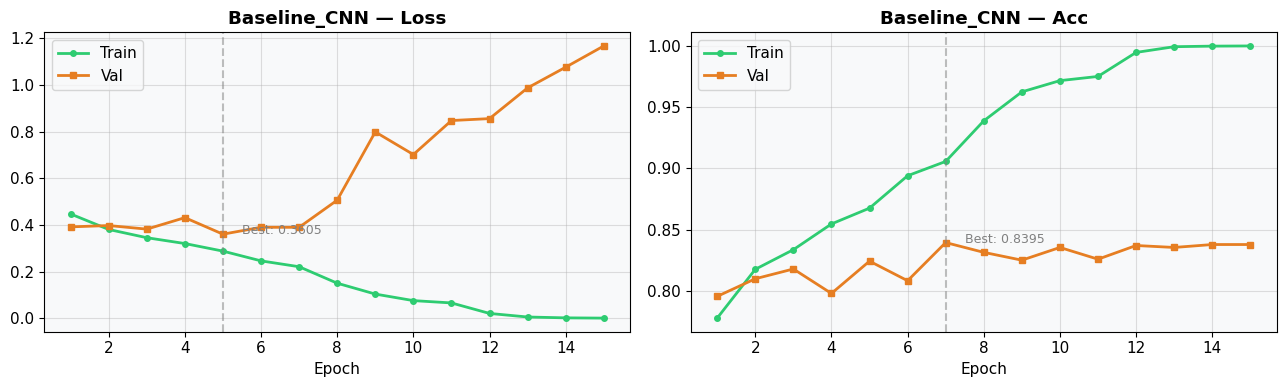

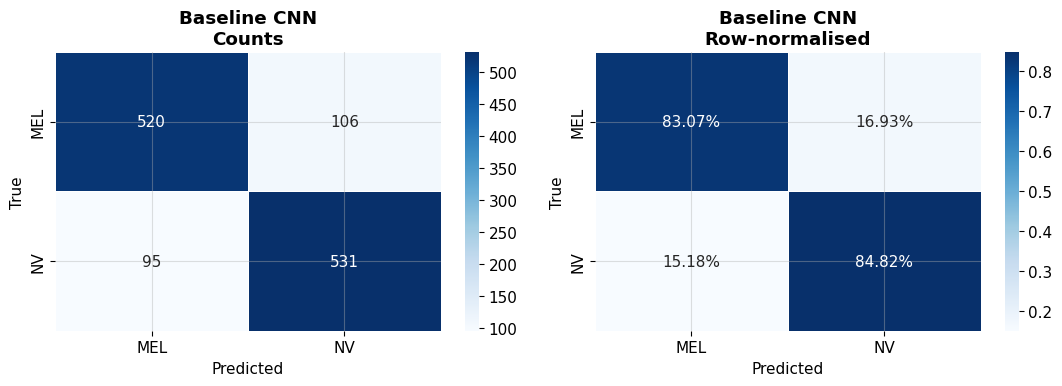

              precision    recall  f1-score   support

         MEL       0.85      0.83      0.84       626
          NV       0.83      0.85      0.84       626

    accuracy                           0.84      1252
   macro avg       0.84      0.84      0.84      1252
weighted avg       0.84      0.84      0.84      1252



In [10]:
train_loader_basic, val_loader = make_loaders(basic_tf, basic_tf)

baseline = BaselineCNN()
h1, acc1 = train_model(baseline, train_loader_basic, val_loader,
                        model_name='Baseline_CNN')
plot_history(h1, 'Baseline_CNN')
_, _, p1, l1 = evaluate(baseline, val_loader)
plot_confusion_matrix(l1, p1, ['MEL','NV'], 'Baseline CNN')
print(classification_report(l1, p1, target_names=['MEL','NV']))

## Experiment 2 : CNN + Batch Normalisation

[BatchNorm_CNN] Ep 01/15  tr_loss=0.7524  tr_acc=0.7635  val_loss=0.4006  val_acc=0.7987
[BatchNorm_CNN] Ep 02/15  tr_loss=0.4033  tr_acc=0.8035  val_loss=0.4033  val_acc=0.7971
[BatchNorm_CNN] Ep 03/15  tr_loss=0.3907  tr_acc=0.8143  val_loss=0.3623  val_acc=0.8163
[BatchNorm_CNN] Ep 04/15  tr_loss=0.3839  tr_acc=0.8204  val_loss=0.3586  val_acc=0.8243
[BatchNorm_CNN] Ep 05/15  tr_loss=0.3707  tr_acc=0.8234  val_loss=0.4204  val_acc=0.8043
[BatchNorm_CNN] Ep 06/15  tr_loss=0.3696  tr_acc=0.8315  val_loss=0.3597  val_acc=0.8339
[BatchNorm_CNN] Ep 07/15  tr_loss=0.3513  tr_acc=0.8372  val_loss=0.3745  val_acc=0.8307
[BatchNorm_CNN] Ep 08/15  tr_loss=0.3505  tr_acc=0.8358  val_loss=0.3455  val_acc=0.8427
[BatchNorm_CNN] Ep 09/15  tr_loss=0.3416  tr_acc=0.8383  val_loss=0.3562  val_acc=0.8323
[BatchNorm_CNN] Ep 10/15  tr_loss=0.3320  tr_acc=0.8470  val_loss=0.3498  val_acc=0.8450
[BatchNorm_CNN] Ep 11/15  tr_loss=0.3261  tr_acc=0.8491  val_loss=0.3545  val_acc=0.8347
[BatchNorm_CNN] Ep 12

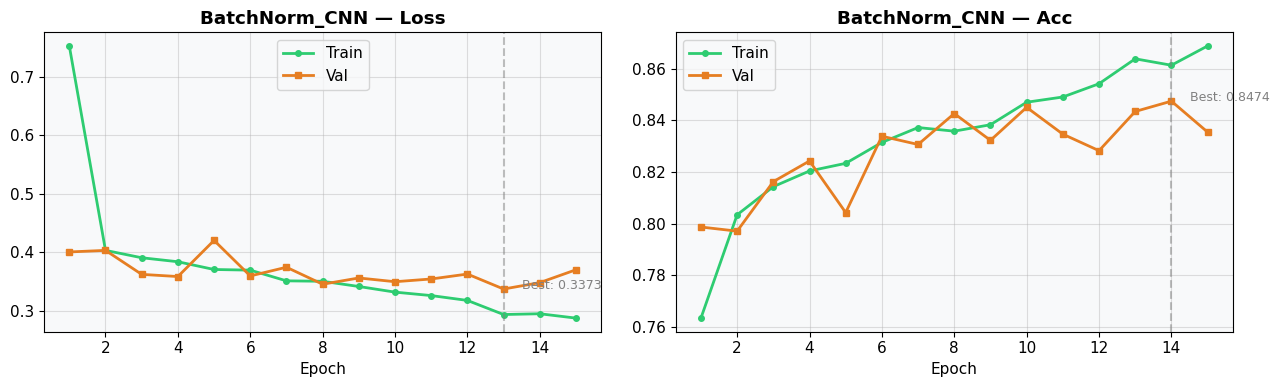

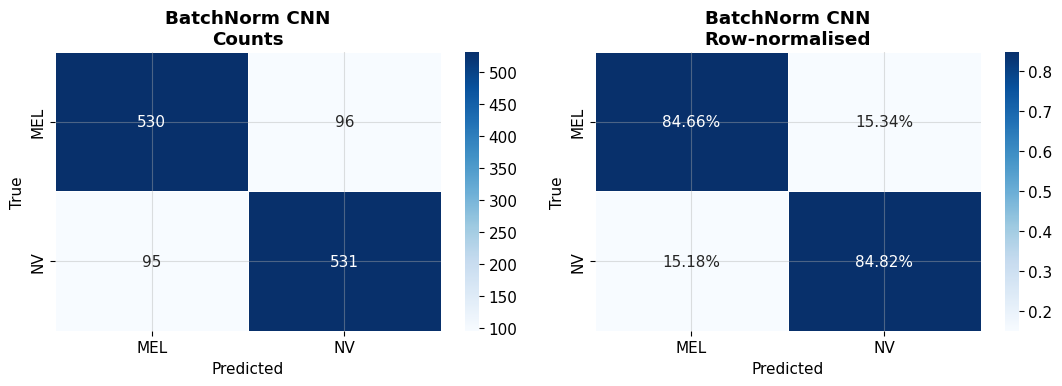

              precision    recall  f1-score   support

         MEL       0.85      0.85      0.85       626
          NV       0.85      0.85      0.85       626

    accuracy                           0.85      1252
   macro avg       0.85      0.85      0.85      1252
weighted avg       0.85      0.85      0.85      1252



In [11]:
bn_model = BatchNormCNN()
h2, acc2 = train_model(bn_model, train_loader_basic, val_loader,
                        model_name='BatchNorm_CNN')
plot_history(h2, 'BatchNorm_CNN')
_, _, p2, l2 = evaluate(bn_model, val_loader)
plot_confusion_matrix(l2, p2, ['MEL','NV'], 'BatchNorm CNN')
print(classification_report(l2, p2, target_names=['MEL','NV']))

##  Experiment 3 : CNN + Residual Connections

[Residual_CNN] Ep 01/15  tr_loss=0.4767  tr_acc=0.7689  val_loss=0.4297  val_acc=0.7660
[Residual_CNN] Ep 02/15  tr_loss=0.4047  tr_acc=0.8041  val_loss=0.3847  val_acc=0.8067
[Residual_CNN] Ep 03/15  tr_loss=0.3884  tr_acc=0.8161  val_loss=0.3759  val_acc=0.8155
[Residual_CNN] Ep 04/15  tr_loss=0.3745  tr_acc=0.8248  val_loss=0.3833  val_acc=0.8195
[Residual_CNN] Ep 05/15  tr_loss=0.3758  tr_acc=0.8210  val_loss=0.3601  val_acc=0.8275
[Residual_CNN] Ep 06/15  tr_loss=0.3539  tr_acc=0.8293  val_loss=0.3621  val_acc=0.8259
[Residual_CNN] Ep 07/15  tr_loss=0.3483  tr_acc=0.8324  val_loss=0.3503  val_acc=0.8387
[Residual_CNN] Ep 08/15  tr_loss=0.3376  tr_acc=0.8405  val_loss=0.3813  val_acc=0.8411
[Residual_CNN] Ep 09/15  tr_loss=0.3382  tr_acc=0.8436  val_loss=0.3409  val_acc=0.8490
[Residual_CNN] Ep 10/15  tr_loss=0.3282  tr_acc=0.8506  val_loss=0.3396  val_acc=0.8442
[Residual_CNN] Ep 11/15  tr_loss=0.3260  tr_acc=0.8531  val_loss=0.3197  val_acc=0.8554
[Residual_CNN] Ep 12/15  tr_loss

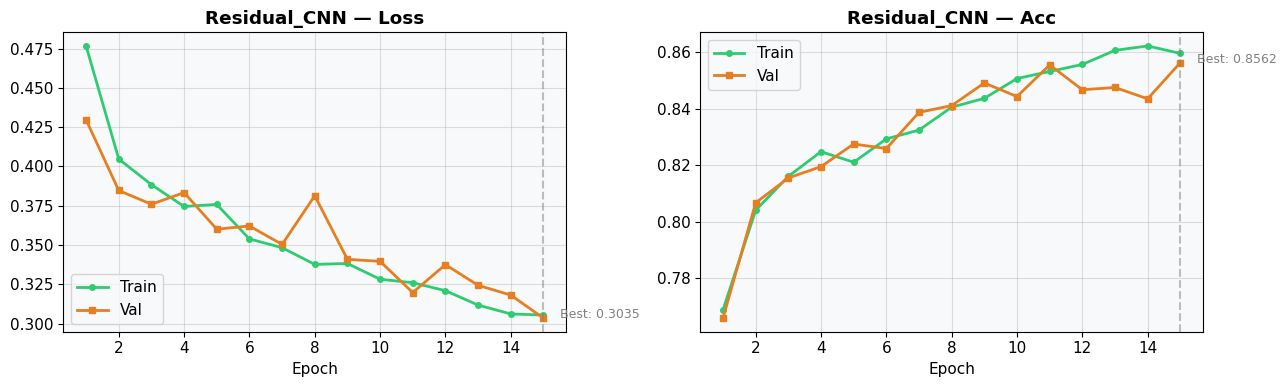

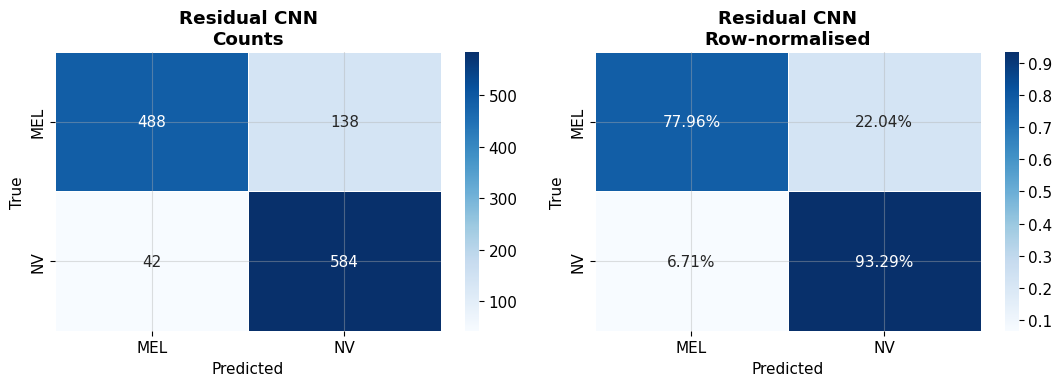

              precision    recall  f1-score   support

         MEL       0.92      0.78      0.84       626
          NV       0.81      0.93      0.87       626

    accuracy                           0.86      1252
   macro avg       0.86      0.86      0.86      1252
weighted avg       0.86      0.86      0.86      1252



In [30]:
res_model = ResidualCNN()
h3, acc3 = train_model(res_model, train_loader_basic, val_loader,
                        model_name='Residual_CNN')
plot_history(h3, 'Residual_CNN')
_, _, p3, l3 = evaluate(res_model, val_loader)
plot_confusion_matrix(l3, p3, ['MEL','NV'], 'Residual CNN')
print(classification_report(l3, p3, target_names=['MEL','NV']))

## Experiment 4: Residual CNN + Data Augmentation

Classes (alphabetical): ['MEL', 'NV']  →  MEL=0, NV=1
Train: 6426 samples | Val: 1252 samples
[Residual_CNN_Aug] Ep 01/15  tr_loss=0.5536  tr_acc=0.7099  val_loss=0.4429  val_acc=0.7708
[Residual_CNN_Aug] Ep 02/15  tr_loss=0.4737  tr_acc=0.7516  val_loss=0.4406  val_acc=0.7524
[Residual_CNN_Aug] Ep 03/15  tr_loss=0.4436  tr_acc=0.7739  val_loss=0.3975  val_acc=0.7891
[Residual_CNN_Aug] Ep 04/15  tr_loss=0.4314  tr_acc=0.7851  val_loss=0.4108  val_acc=0.7804
[Residual_CNN_Aug] Ep 05/15  tr_loss=0.4372  tr_acc=0.7828  val_loss=0.4270  val_acc=0.8027
[Residual_CNN_Aug] Ep 06/15  tr_loss=0.4291  tr_acc=0.7874  val_loss=0.3846  val_acc=0.7947
[Residual_CNN_Aug] Ep 07/15  tr_loss=0.4126  tr_acc=0.8025  val_loss=0.3870  val_acc=0.8027
[Residual_CNN_Aug] Ep 08/15  tr_loss=0.4180  tr_acc=0.7988  val_loss=0.3742  val_acc=0.8091
[Residual_CNN_Aug] Ep 09/15  tr_loss=0.3994  tr_acc=0.8056  val_loss=0.3581  val_acc=0.8203
[Residual_CNN_Aug] Ep 10/15  tr_loss=0.4036  tr_acc=0.8059  val_loss=0.3637  v

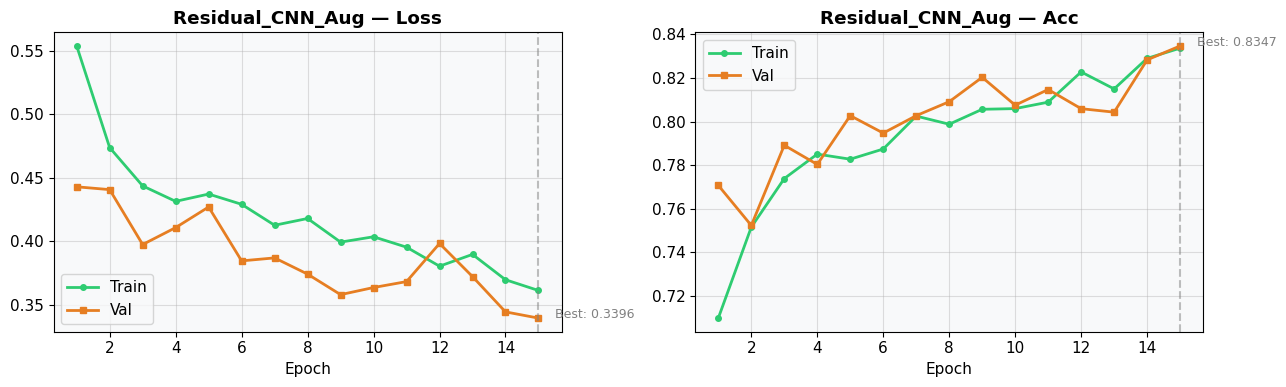

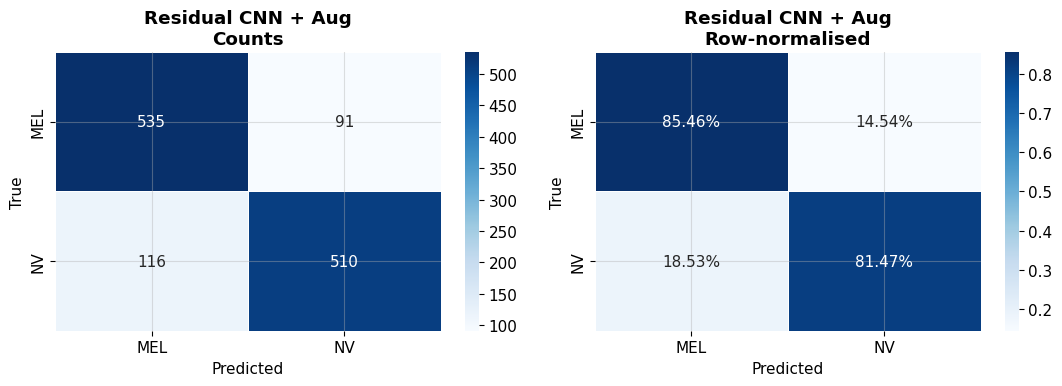

              precision    recall  f1-score   support

         MEL       0.82      0.85      0.84       626
          NV       0.85      0.81      0.83       626

    accuracy                           0.83      1252
   macro avg       0.84      0.83      0.83      1252
weighted avg       0.84      0.83      0.83      1252



In [13]:
aug_tf = get_augmented_transform()
train_loader_aug, _ = make_loaders(aug_tf, basic_tf)

aug_model = ResidualCNN()
h4, acc4 = train_model(aug_model, train_loader_aug, val_loader,
                        model_name='Residual_CNN_Aug')
plot_history(h4, 'Residual_CNN_Aug')
_, _, p4, l4 = evaluate(aug_model, val_loader)
plot_confusion_matrix(l4, p4, ['MEL','NV'], 'Residual CNN + Aug')
print(classification_report(l4, p4, target_names=['MEL','NV']))

## Experiment 5: Transfer Learning (Frozen VGG-16)

Computing VGG features for "train" (first run only)...
Computing VGG features for "val" (first run only)...
Iteration 1, loss = 0.56349273
Iteration 2, loss = 0.12792777
Iteration 3, loss = 0.03280826
Iteration 4, loss = 0.01047263
Iteration 5, loss = 0.00302487
Iteration 6, loss = 0.00180049
Iteration 7, loss = 0.00138096
Iteration 8, loss = 0.00116792
Iteration 9, loss = 0.00102160
Iteration 10, loss = 0.00092388
Iteration 11, loss = 0.00085372
Iteration 12, loss = 0.00079564
Iteration 13, loss = 0.00075372
Iteration 14, loss = 0.00072002
Iteration 15, loss = 0.00069214
Iteration 16, loss = 0.00066957
Iteration 17, loss = 0.00065104
Iteration 18, loss = 0.00063462
Iteration 19, loss = 0.00062068
Iteration 20, loss = 0.00060882
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

VGG-16 Transfer Learning Val Accuracy: 0.8626
              precision    recall  f1-score   support

         MEL       0.86      0.87      0.86       626
          NV   

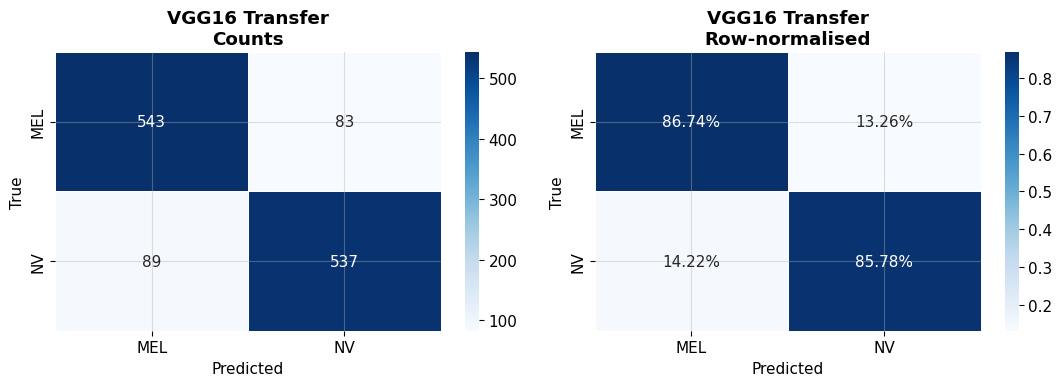

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

def precompute_vgg_features(split_dir, split_name, cache_dir='vgg_features'):
    os.makedirs(cache_dir, exist_ok=True)
    feat_path  = os.path.join(cache_dir, f'{split_name}_features.npy')
    label_path = os.path.join(cache_dir, f'{split_name}_labels.npy')
    if os.path.exists(feat_path) and os.path.exists(label_path):
        print(f'Loading cached VGG features for "{split_name}"...')
        return np.load(feat_path), np.load(label_path)
    print(f'Computing VGG features for "{split_name}" (first run only)...')
    weights_id = torchvision.models.VGG16_Weights.IMAGENET1K_V1
    vgg = torchvision.models.vgg16(weights=weights_id).to(device).eval()
    vgg_tf = weights_id.transforms()
    ds = ImageFolder(split_dir, transform=vgg_tf)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    fl, ll = [], []
    with torch.no_grad():
        for X, y in loader:
            f = vgg.avgpool(vgg.features(X.to(device)))
            fl.append(f.view(f.size(0), -1).cpu().numpy())
            ll.append(y.numpy())
    features, labels = np.concatenate(fl), np.concatenate(ll)
    np.save(feat_path, features); np.save(label_path, labels)
    return features, labels

X_tr_v, y_tr_v = precompute_vgg_features(TRAIN_DIR, 'train')
X_vl_v, y_vl_v = precompute_vgg_features(VAL_DIR,   'val')

scaler = StandardScaler()
X_tr_v = scaler.fit_transform(X_tr_v)
X_vl_v = scaler.transform(X_vl_v)

clf = MLPClassifier(hidden_layer_sizes=(512, 128), max_iter=30, random_state=SEED, verbose=True)
clf.fit(X_tr_v, y_tr_v)

p5   = clf.predict(X_vl_v)
acc5 = accuracy_score(y_vl_v, p5)
print(f'\nVGG-16 Transfer Learning Val Accuracy: {acc5:.4f}')
print(classification_report(y_vl_v, p5, target_names=['MEL','NV']))
plot_confusion_matrix(y_vl_v.tolist(), p5.tolist(), ['MEL','NV'], 'VGG16 Transfer')

## Results Summary 


Model                                       Val Acc
-------------------------------------------------------
5. Transfer (VGG-16)                         0.8626
3. CNN + Residual                            0.8562
2. CNN + BatchNorm                           0.8474
1. Baseline CNN                              0.8395
4. Residual + Augmentation                   0.8347


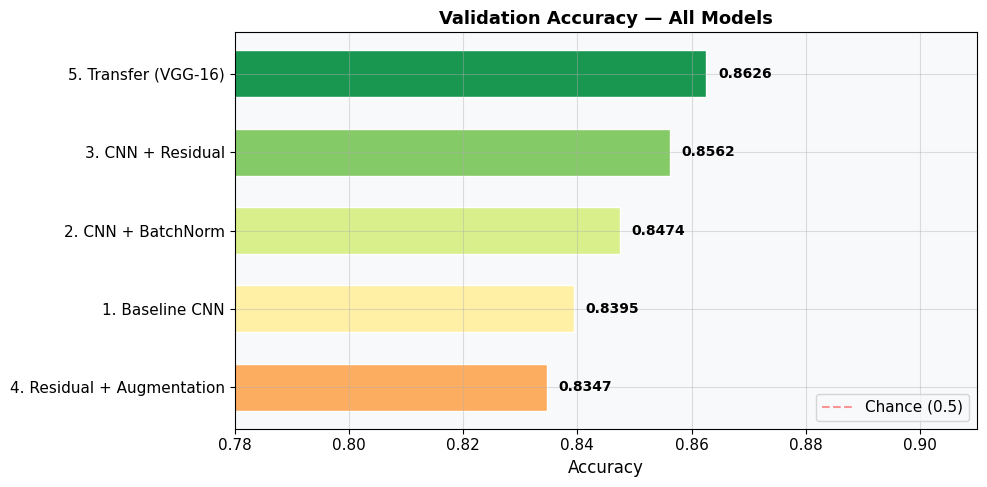

In [31]:
results = {
    '1. Baseline CNN':               acc1,
    '2. CNN + BatchNorm':            acc2,
    '3. CNN + Residual':             acc3,
    '4. Residual + Augmentation':    acc4,
    '5. Transfer (VGG-16)':          acc5,
  
}


print('\n' + '='*55)
print(f'{"Model":<40} {"Val Acc":>10}')
print('-'*55)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{name:<40} {acc:>10.4f}')
print('='*55)


plot_comparison(results, title='Validation Accuracy — All Models', save_name='model_comparison')

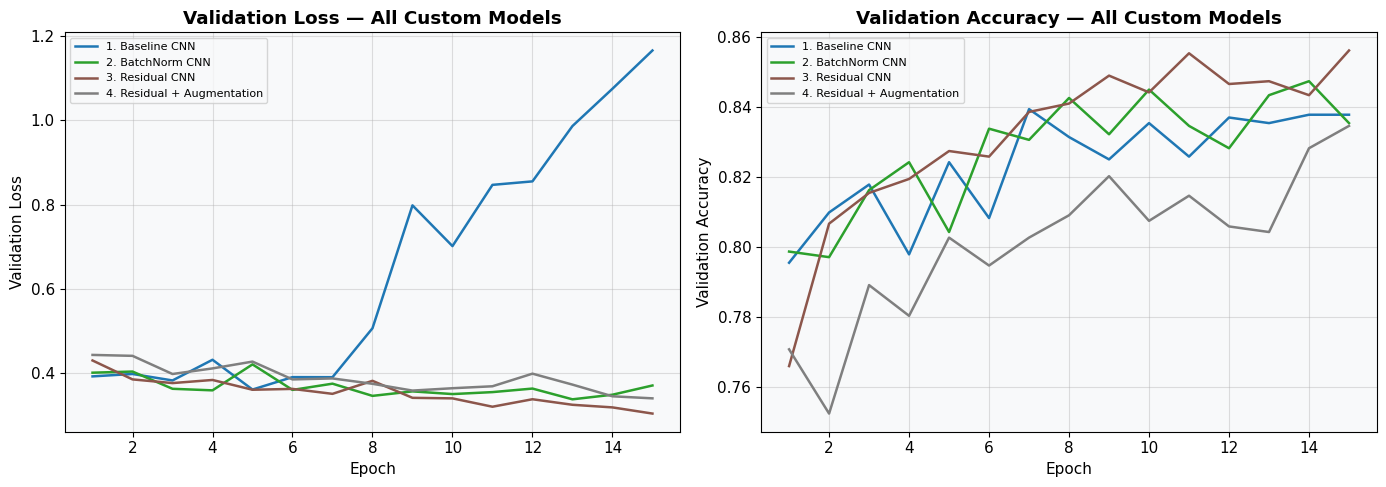

In [32]:
#  training curves for all  models 
histories = {
    '1. Baseline CNN':            h1,
    '2. BatchNorm CNN':           h2,
    '3. Residual CNN':            h3,
    '4. Residual + Augmentation': h4,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.tab10
for idx, (name, h) in enumerate(histories.items()):
    c  = cmap(idx / len(histories))
    ep = range(1, len(h['val_acc']) + 1)
    axes[0].plot(ep, h['val_loss'], color=c, lw=1.8, label=name)
    axes[1].plot(ep, h['val_acc'],  color=c, lw=1.8, label=name)

for ax, ylabel, title in zip(
    axes,
    ['Validation Loss', 'Validation Accuracy'],
    ['Validation Loss — All Custom Models', 'Validation Accuracy — All Custom Models']
):
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('all_models_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Test Set Evaluation

Loading cached VGG features for "test"...

TEST SET RESULTS — Transfer Learning (VGG-16)
Test Accuracy: 0.8616
              precision    recall  f1-score   support

         MEL       0.86      0.86      0.86       683
          NV       0.86      0.86      0.86       683

    accuracy                           0.86      1366
   macro avg       0.86      0.86      0.86      1366
weighted avg       0.86      0.86      0.86      1366



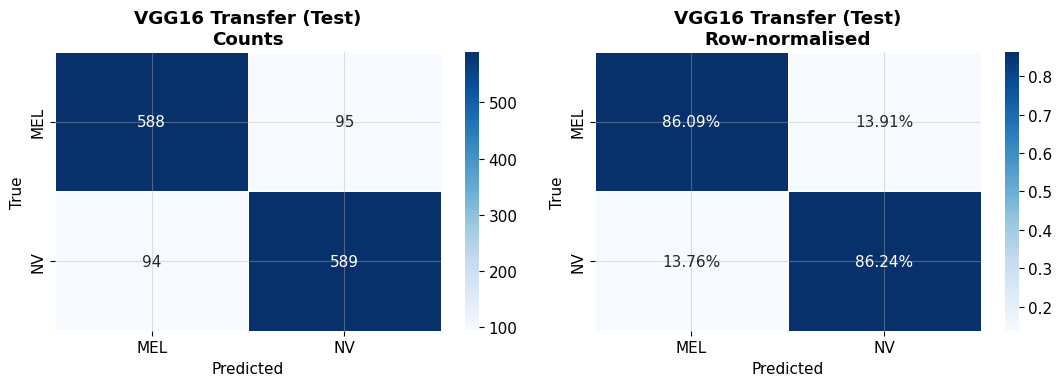

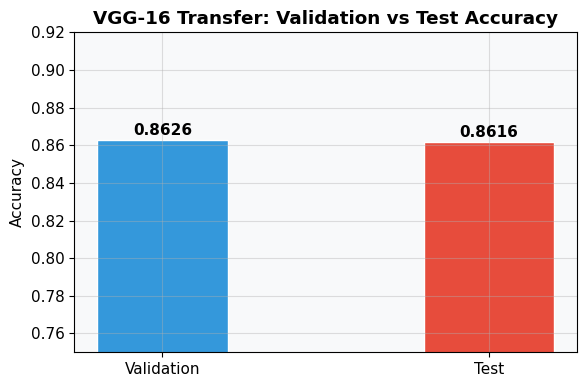

In [ ]:
# test Set Evaluation Transfer Learning 
if os.path.exists(TEST_DIR):
    
    X_test_vgg, y_test_vgg = precompute_vgg_features(TEST_DIR, 'test')
    X_test_vgg_scaled = scaler.transform(X_test_vgg)   # use the scaler fitted on train

    test_preds_vgg = clf.predict(X_test_vgg_scaled)
    test_acc_vgg   = accuracy_score(y_test_vgg, test_preds_vgg)

    print('\n' + '='*50)
    print('TEST SET RESULTS — Transfer Learning (VGG-16)')
    print('='*50)
    print(f'Test Accuracy: {test_acc_vgg:.4f}')
    print(classification_report(y_test_vgg, test_preds_vgg,
                                 target_names=['MEL', 'NV']))

    plot_confusion_matrix(y_test_vgg.tolist(), test_preds_vgg.tolist(),
                          ['MEL', 'NV'], 'VGG16 Transfer (Test)')

    # Val vs Test comparison
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(['Validation', 'Test'], [acc5, test_acc_vgg],
                  color=['#3498db', '#e74c3c'], width=0.4, edgecolor='white')
    for bar, val in zip(bars, [acc5, test_acc_vgg]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontweight='bold')
    ax.set_ylim(0.75, 0.92)
    ax.set_ylabel('Accuracy')
    ax.set_title('VGG-16 Transfer: Validation vs Test Accuracy', fontweight='bold')
    plt.tight_layout()
    plt.savefig('vgg_val_vs_test.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Test directory "{TEST_DIR}" not found.')

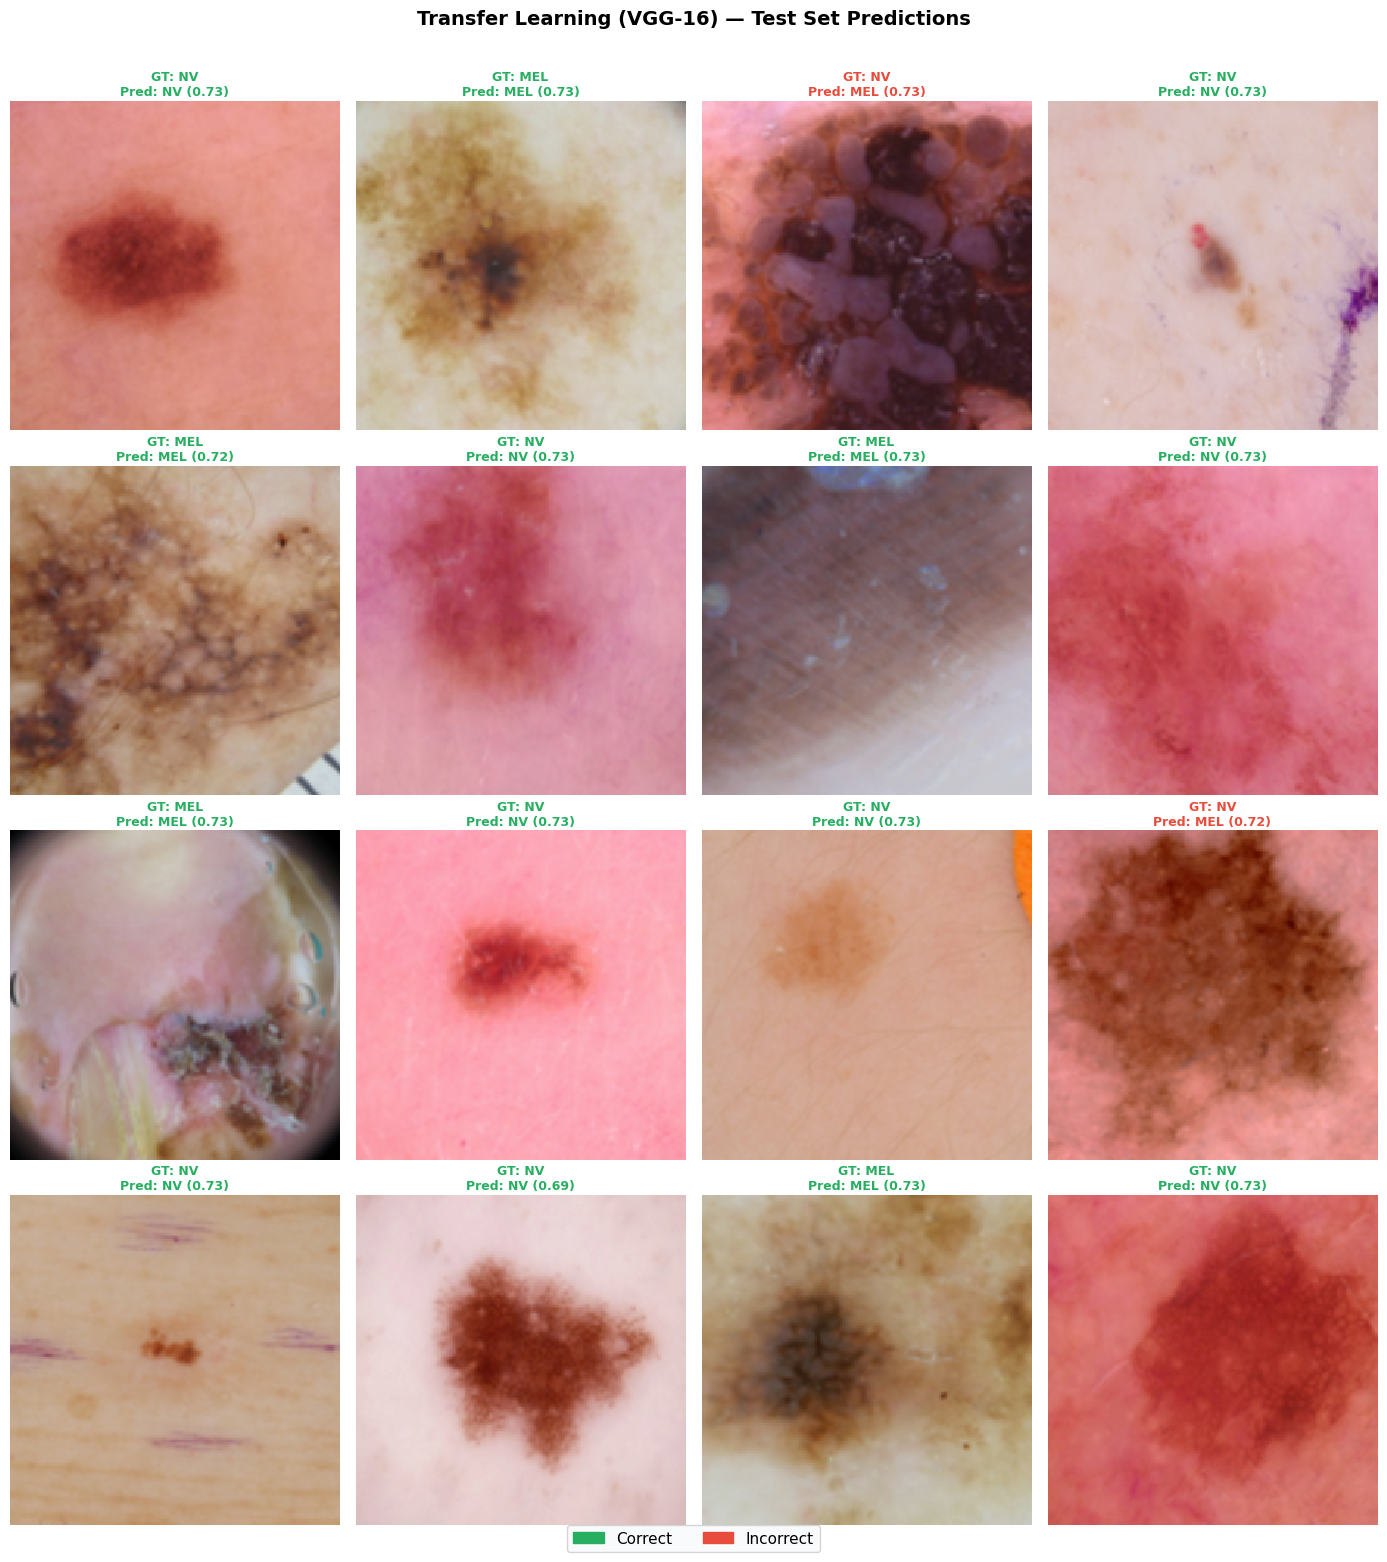

In [41]:
def plot_predictions(model, dataset, class_names, n_images=16, title='Predictions', save_name='predictions'):

    model.eval()
    indices   = np.random.choice(len(dataset), n_images, replace=False)
    n_cols    = 4
    n_rows    = n_images // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.8))
    axes      = axes.flatten()

    for ax, idx in zip(axes, indices):
        img_tensor, true_label = dataset[idx]

        #run inference
        with torch.no_grad():
            logits = model(img_tensor.unsqueeze(0).to(device))
            probs  = torch.softmax(logits, dim=1).cpu().squeeze()

        pred_label = probs.argmax().item()
        confidence = probs[pred_label].item()
        correct    = pred_label == true_label
        img = unnormalise(img_tensor)# undo normalisation for display

        ax.imshow(img, interpolation='none')
        ax.axis('off')

        pred_name = class_names[pred_label]
        true_name = class_names[true_label]
        color     = '#27ae60' if correct else '#e74c3c'

        ax.set_title(
            f'GT: {true_name}\nPred: {pred_name} ({confidence:.2f})',
            fontsize=9, color=color, fontweight='bold',
            pad=4
        )
      
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

  
    correct_patch = mpatches.Patch(color='#27ae60', label='Correct')
    wrong_patch   = mpatches.Patch(color='#e74c3c', label='Incorrect')
    fig.legend(handles=[correct_patch, wrong_patch],
               loc='lower center', ncol=2, fontsize=11,
               bbox_to_anchor=(0.5, -0.01))

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


# load the test dataset 
if os.path.exists(TEST_DIR):
    test_ds_vis = ImageFolder(TEST_DIR, transform=basic_tf)

    class VGGSklearnWrapper(nn.Module):
        def __init__(self, vgg_features, vgg_avgpool, sklearn_clf, sklearn_scaler):
            super().__init__()
            self.features = vgg_features
            self.avgpool  = vgg_avgpool
            self.clf      = sklearn_clf
            self.scaler   = sklearn_scaler

        def forward(self, x):
            with torch.no_grad():
                f = self.avgpool(self.features(x.to(device)))
                f = f.view(f.size(0), -1).cpu().numpy()
            f_scaled = self.scaler.transform(f)
            probs    = self.clf.predict_proba(f_scaled)    # (B, 2)
            return torch.tensor(probs, dtype=torch.float32)      # logits-compatible

    weights_id  = torchvision.models.VGG16_Weights.IMAGENET1K_V1
    vgg_raw     = torchvision.models.vgg16(weights=weights_id).to(device).eval()
    vgg_wrapper = VGGSklearnWrapper(vgg_raw.features, vgg_raw.avgpool, clf, scaler)
    
    test_ds_vgg = ImageFolder(TEST_DIR, transform=weights_id.transforms()) # VGG needs its own preprocessing transform

    plot_predictions(vgg_wrapper, test_ds_vgg,
                     class_names=test_ds_vgg.classes,
                     n_images=16,
                     title='Transfer Learning (VGG-16) — Test Set Predictions',
                     save_name='vgg_predictions')
else:
    print(f'Test directory "{TEST_DIR}" not found.')